In [1]:
import pandas as pd

## 1. Load prepared lyrics dataset

In [2]:
lyrics_df = pd.read_csv(
    "../data/processed/final/lyrics_prepared.csv"
)

In [3]:
lyrics_df.shape

(540, 17)

In [5]:
lyrics_df["lyrics_status"].value_counts(dropna=False)

lyrics_status
retrieved_lyrics    539
instrumental          1
Name: count, dtype: int64

In [6]:
lyrics_df["language"].value_counts(dropna=False)

language
english       523
polish          9
french          3
unknown         1
indonesian      1
italian         1
chinese         1
NaN             1
Name: count, dtype: int64

## 2. Prepare the English lyrics corpus

In [7]:
english_lyrics = lyrics_df[
    (lyrics_df["lyrics_status"] == "retrieved_lyrics") & (lyrics_df["language"] == "english")
].copy()

In [8]:
english_lyrics.shape

(523, 17)

## 3. Load the NRC Emotion Lexicon

In [9]:
nrc_path = (
    "../data/nrc_lexicon/"
    "NRC-Suite-of-Sentiment-Emotion-Lexicons/"
    "NRC-Sentiment-Emotion-Lexicons/"
    "NRC-Emotion-Lexicon-v0.92/"
    "NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
)

nrc = pd.read_csv(
    nrc_path,
    sep="\t",
    header=None
)

nrc.head()

,0,1,2
0,aback,anger,0
1,aback,anticipation,0
2,aback,disgust,0
3,aback,fear,0
4,aback,joy,0


In [10]:
nrc.columns = ["word", "category", "association"]

nrc.head()

,word,category,association
0,aback,anger,0
1,aback,anticipation,0
2,aback,disgust,0
3,aback,fear,0
4,aback,joy,0


In [11]:
nrc["category"].unique()

<ArrowStringArray>
[       'anger', 'anticipation',      'disgust',         'fear',
          'joy',     'negative',     'positive',      'sadness',
     'surprise',        'trust']
Length: 10, dtype: str

In [12]:
nrc["category"].value_counts()

category
anger           14154
anticipation    14154
disgust         14154
fear            14154
joy             14154
negative        14154
positive        14154
sadness         14154
surprise        14154
trust           14154
Name: count, dtype: int64

In [14]:
# We don't need all rows with association = 0. We're only interested in words that are truly associated by NRC with particular sentiments and emotions.

nrc_active = nrc[nrc["association"] == 1].copy()

nrc_active.head()

,word,category,association
19,abacus,trust,1
23,abandon,fear,1
25,abandon,negative,1
27,abandon,sadness,1
30,abandoned,anger,1


In [15]:
nrc_active["category"].value_counts()

category
negative        3316
positive        2308
fear            1474
anger           1245
trust           1230
sadness         1187
disgust         1056
anticipation     837
joy              687
surprise         532
Name: count, dtype: int64

In [ ]:
# Check case of words and whitespaces

nrc_active["word"] = (nrc_active["word"].str.lower().str.strip())

nrc_active["word"].duplicated().sum()

np.int64(7419)

In [18]:
# Check duplicates of word-category pairs. There should be none.

nrc_active.duplicated(
    subset=["word", "category"]
).sum()

np.int64(0)

In [20]:
nrc_lookup = (nrc_active.groupby("word")["category"].agg(list).to_dict())

In [21]:
nrc_lookup["abandon"]

['fear', 'negative', 'sadness']

In [22]:
nrc_lookup["joy"]

['joy', 'positive']

## 4. Build track-level emotion profiles

In [23]:
import re

def tokenize_lyrics(text):
    return re.findall(r"[a-z]+", str(text).lower())

In [24]:
test_lyrics = english_lyrics["lyrics_clean"].iloc[0]

tokenize_lyrics(test_lyrics)[:30]

['if',
 'i',
 'had',
 'my',
 'own',
 'world',
 'i',
 'd',
 'build',
 'you',
 'an',
 'empire',
 'if',
 'i',
 'had',
 'my',
 'own',
 'world',
 'i',
 'd',
 'fill',
 'it',
 'with',
 'wealth',
 'and',
 'desire',
 'a',
 'glorious',
 'past',
 'to']

In [25]:
def get_nrc_matches(text):
    tokens = tokenize_lyrics(text)
    
    matched_tokens = []
    matched_categories = []
    
    for token in tokens:
        categories = nrc_lookup.get(token)
        if categories:
            matched_tokens.append(token)
            matched_categories.extend(categories)
            
    return {
        "total_tokens": len(tokens),
        "matched_tokens": len(matched_tokens),
        "matched_categories": matched_categories
    }

In [26]:
test_result = get_nrc_matches(test_lyrics)
test_result

{'total_tokens': 373,
 'matched_tokens': 54,
 'matched_categories': ['positive',
  'trust',
  'joy',
  'positive',
  'trust',
  'positive',
  'trust',
  'joy',
  'positive',
  'anger',
  'anticipation',
  'disgust',
  'fear',
  'negative',
  'sadness',
  'surprise',
  'fear',
  'positive',
  'trust',
  'positive',
  'joy',
  'positive',
  'anger',
  'fear',
  'negative',
  'sadness',
  'positive',
  'joy',
  'positive',
  'anger',
  'fear',
  'negative',
  'sadness',
  'anticipation',
  'fear',
  'anger',
  'negative',
  'anticipation',
  'joy',
  'positive',
  'surprise',
  'trust',
  'fear',
  'trust',
  'anticipation',
  'joy',
  'positive',
  'sadness',
  'trust',
  'trust',
  'positive',
  'trust',
  'joy',
  'positive',
  'trust',
  'anticipation',
  'fear',
  'joy',
  'positive',
  'trust',
  'anticipation',
  'joy',
  'positive',
  'surprise',
  'trust',
  'positive',
  'joy',
  'positive',
  'anger',
  'fear',
  'negative',
  'sadness',
  'positive',
  'joy',
  'positive',
  '

In [27]:
# matched_tokens = 54 means that 54 text tokens were found in the NRC lexicon. Not 54 different words, but 54 instances of words that are in the lexicon. For example, if the word "love" appears 10 times in the lyrics, it will be counted as 10 matched tokens.

In [28]:
nrc_results = english_lyrics["lyrics_clean"].apply(get_nrc_matches)

In [31]:
nrc_results[0]

{'total_tokens': 373,
 'matched_tokens': 54,
 'matched_categories': ['positive',
  'trust',
  'joy',
  'positive',
  'trust',
  'positive',
  'trust',
  'joy',
  'positive',
  'anger',
  'anticipation',
  'disgust',
  'fear',
  'negative',
  'sadness',
  'surprise',
  'fear',
  'positive',
  'trust',
  'positive',
  'joy',
  'positive',
  'anger',
  'fear',
  'negative',
  'sadness',
  'positive',
  'joy',
  'positive',
  'anger',
  'fear',
  'negative',
  'sadness',
  'anticipation',
  'fear',
  'anger',
  'negative',
  'anticipation',
  'joy',
  'positive',
  'surprise',
  'trust',
  'fear',
  'trust',
  'anticipation',
  'joy',
  'positive',
  'sadness',
  'trust',
  'trust',
  'positive',
  'trust',
  'joy',
  'positive',
  'trust',
  'anticipation',
  'fear',
  'joy',
  'positive',
  'trust',
  'anticipation',
  'joy',
  'positive',
  'surprise',
  'trust',
  'positive',
  'joy',
  'positive',
  'anger',
  'fear',
  'negative',
  'sadness',
  'positive',
  'joy',
  'positive',
  '

In [29]:
nrc_results_df = pd.DataFrame(
    nrc_results.tolist(),
    index=english_lyrics.index
)

In [32]:
nrc_results_df.head()

,total_tokens,matched_tokens,matched_categories
0,373,54,"[positive, trust, joy, positive, trust, positi..."
1,270,21,"[joy, positive, trust, joy, positive, trust, p..."
2,266,44,"[anticipation, joy, positive, trust, anger, ne..."
3,430,43,"[anticipation, anticipation, joy, positive, tr..."
4,231,27,"[positive, anticipation, joy, positive, negati..."


In [33]:
english_lyrics = english_lyrics.join(nrc_results_df)

In [34]:
english_lyrics[
    [
        "artist",
        "track",
        "total_tokens",
        "matched_tokens",
        "matched_categories"
    ]
].head()

,artist,track,total_tokens,matched_tokens,matched_categories
0,Angels & Airwaves,Secret Crowds,373,54,"[positive, trust, joy, positive, trust, positi..."
1,Red Hot Chili Peppers,Monarchy of Roses,270,21,"[joy, positive, trust, joy, positive, trust, p..."
2,Brandon Flowers,Only the Young,266,44,"[anticipation, joy, positive, trust, anger, ne..."
3,Pennywise,Living for Today,430,43,"[anticipation, anticipation, joy, positive, tr..."
4,Katie Melua,The Closest Thing to Crazy,231,27,"[positive, anticipation, joy, positive, negati..."


In [35]:
english_lyrics["lexicon_coverage"] = english_lyrics["matched_tokens"] / english_lyrics["total_tokens"]

In [36]:
english_lyrics["lexicon_coverage"].describe()

count    523.000000
mean       0.106657
std        0.051265
min        0.000000
25%        0.071310
50%        0.100000
75%        0.134358
max        0.382353
Name: lexicon_coverage, dtype: float64

In [37]:
# NRC lets us classify ca 1 out of 10 tokens (50% = 0.10). So only 10% of the words in the lyrics are found in the NRC lexicon. This is a limitation of using a lexicon-based approach, as it may not capture all the nuances of sentiment and emotion in the lyrics.

## 5. Sentiment and emotional balance

In [38]:
from collections import Counter

def count_nrc_categories(categories):
    counts = Counter(categories)
    
    return {category: counts.get(category, 0) for category in nrc["category"].unique()}

In [39]:
test_counts = count_nrc_categories(
    test_result["matched_categories"]
)

test_counts

{'anger': 10,
 'anticipation': 18,
 'disgust': 1,
 'fear': 17,
 'joy': 19,
 'negative': 10,
 'positive': 27,
 'sadness': 10,
 'surprise': 7,
 'trust': 24}

In [40]:
emotion_counts = english_lyrics["matched_categories"].apply(count_nrc_categories)

In [41]:
emotion_counts_df = pd.DataFrame(
    emotion_counts.tolist(),
    index=english_lyrics.index
)

In [42]:
emotion_counts_df.head()

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
0,10,18,1,17,19,10,27,10,7,24
1,4,1,1,3,7,5,10,3,1,9
2,3,10,1,1,11,12,14,12,18,8
3,9,28,6,11,16,11,17,7,3,16
4,10,8,4,11,9,15,10,14,8,5


In [43]:
english_lyrics = english_lyrics.join(emotion_counts_df)

In [44]:
english_lyrics[
    [
        "artist",
        "track",
        "total_tokens",
        "matched_tokens",
        "lexicon_coverage",
        "anger",
        "anticipation",
        "disgust",
        "fear",
        "joy",
        "sadness",
        "surprise",
        "trust",
        "positive",
        "negative"
    ]
].head()

,artist,track,total_tokens,matched_tokens,lexicon_coverage,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
0,Angels & Airwaves,Secret Crowds,373,54,0.144772,10,18,1,17,19,10,7,24,27,10
1,Red Hot Chili Peppers,Monarchy of Roses,270,21,0.077778,4,1,1,3,7,3,1,9,10,5
2,Brandon Flowers,Only the Young,266,44,0.165414,3,10,1,1,11,12,18,8,14,12
3,Pennywise,Living for Today,430,43,0.100000,9,28,6,11,16,7,3,16,17,11
4,Katie Melua,The Closest Thing to Crazy,231,27,0.116883,10,8,4,11,9,14,8,5,10,15


In [45]:
# Create emotional profiles

emotion_categories = [
    "anger",
    "anticipation",
    "disgust",
    "fear",
    "joy",
    "sadness",
    "surprise",
    "trust"
]

In [46]:
english_lyrics["emotion_total"] = (english_lyrics[emotion_categories].sum(axis=1))

In [47]:
for emotion in emotion_categories:
    english_lyrics[f"{emotion}_share"] = english_lyrics[emotion] / english_lyrics["emotion_total"]

In [48]:
english_lyrics[
    [
        "artist",
        "track",
        "emotion_total",
        "anger_share",
        "anticipation_share",
        "disgust_share",
        "fear_share",
        "joy_share",
        "sadness_share",
        "surprise_share",
        "trust_share"
    ]
].head()

,artist,track,emotion_total,anger_share,anticipation_share,disgust_share,fear_share,joy_share,sadness_share,surprise_share,trust_share
0,Angels & Airwaves,Secret Crowds,106,0.094340,0.169811,0.009434,0.160377,0.179245,0.094340,0.066038,0.226415
1,Red Hot Chili Peppers,Monarchy of Roses,29,0.137931,0.034483,0.034483,0.103448,0.241379,0.103448,0.034483,0.310345
2,Brandon Flowers,Only the Young,64,0.046875,0.156250,0.015625,0.015625,0.171875,0.187500,0.281250,0.125000
3,Pennywise,Living for Today,96,0.093750,0.291667,0.062500,0.114583,0.166667,0.072917,0.031250,0.166667
4,Katie Melua,The Closest Thing to Crazy,69,0.144928,0.115942,0.057971,0.159420,0.130435,0.202899,0.115942,0.072464


In [49]:
english_lyrics[
    [f"{emotion}_share" for emotion in emotion_categories]
].sum(axis=1).describe()

count    523.000000
mean       0.982792
std        0.130172
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
dtype: float64

In [50]:
# Check how many songs have no emotional content (emotion_total = 0). This is possible if the lyrics contain no words that are found in the NRC lexicon, or contain only "positive" or "negative" matches.
english_lyrics["emotion_total"].eq(0).sum()

np.int64(9)

In [51]:
english_lyrics.loc[
    english_lyrics["emotion_total"] == 0,
    [
        "artist",
        "track",
        "total_tokens",
        "matched_tokens",
        "lexicon_coverage",
        "positive",
        "negative",
        "emotion_total"
    ]
]

,artist,track,total_tokens,matched_tokens,lexicon_coverage,positive,negative,emotion_total
31,Dead Man's Bones,Young & Tragic,15,1,0.066667,0,1,0
193,M83,"Soon, My Friend",34,0,0.000000,0,0,0
259,Carbon Based Lifeforms,Abiogenesis,47,0,0.000000,0,0,0
265,Bang Gang,Find What You Get,96,4,0.041667,4,0,0
279,Boy Azooga,Face Behind Her Cigarette,77,11,0.142857,0,11,0
281,Kelly Lee Owens,Melt!,7,0,0.000000,0,0,0
291,This Mortal Coil,A Single Wish (remastered),25,0,0.000000,0,0,0
422,Everything Is Recorded,This Is What Happens,45,0,0.000000,0,0,0
480,Fog Lake,inference (i),76,2,0.026316,2,0,0


In [53]:
import numpy as np

emotion_share_columns = [
    f"{emotion}_share"
    for emotion in emotion_categories
]

english_lyrics.loc[
    english_lyrics["emotion_total"] == 0,
    emotion_share_columns
] = np.nan

In [54]:
english_lyrics.loc[
    english_lyrics["emotion_total"] == 0,
    [
        "artist",
        "track",
        "emotion_total",
        "anger_share",
        "joy_share",
        "sadness_share",
        "trust_share"
    ]
]

,artist,track,emotion_total,anger_share,joy_share,sadness_share,trust_share
31,Dead Man's Bones,Young & Tragic,0,NaN,NaN,NaN,NaN
193,M83,"Soon, My Friend",0,NaN,NaN,NaN,NaN
259,Carbon Based Lifeforms,Abiogenesis,0,NaN,NaN,NaN,NaN
265,Bang Gang,Find What You Get,0,NaN,NaN,NaN,NaN
279,Boy Azooga,Face Behind Her Cigarette,0,NaN,NaN,NaN,NaN
281,Kelly Lee Owens,Melt!,0,NaN,NaN,NaN,NaN
291,This Mortal Coil,A Single Wish (remastered),0,NaN,NaN,NaN,NaN
422,Everything Is Recorded,This Is What Happens,0,NaN,NaN,NaN,NaN
480,Fog Lake,inference (i),0,NaN,NaN,NaN,NaN


In [55]:
english_lyrics.loc[
    english_lyrics["emotion_total"] > 0,
    emotion_share_columns
].sum(axis=1).describe()

count    5.140000e+02
mean     1.000000e+00
std      6.428591e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

### 5.1 Sentiment balance

In [56]:
# positive + negative are not included in the emotion share columns, so they are not included in the sum. The sum of the emotion shares should be 1 for all songs with emotional content (emotion_total > 0).

sentiment_total = (
    english_lyrics["positive"]
    + english_lyrics["negative"]
)

english_lyrics["sentiment_total"] = sentiment_total

In [58]:
english_lyrics["positive_share"] = english_lyrics["positive"] / english_lyrics["sentiment_total"]

english_lyrics["negative_share"] = english_lyrics["negative"] / english_lyrics["sentiment_total"]

In [60]:
english_lyrics["sentiment_total"].eq(0).sum()

np.int64(8)

In [61]:
sentiment_share_columns = [
    "positive_share",
    "negative_share"
]

english_lyrics.loc[
    english_lyrics["sentiment_total"] == 0,
    sentiment_share_columns
] = np.nan

In [62]:
english_lyrics.loc[
    english_lyrics["sentiment_total"] == 0,
    [
        "artist",
        "track",
        "total_tokens",
        "matched_tokens",
        "lexicon_coverage",
        "positive",
        "negative",
        "sentiment_total",
        "positive_share",
        "negative_share"
    ]
]

,artist,track,total_tokens,matched_tokens,lexicon_coverage,positive,negative,sentiment_total,positive_share,negative_share
109,Air,Kelly Watch the Stars,76,17,0.223684,0,0,0,NaN,NaN
193,M83,"Soon, My Friend",34,0,0.000000,0,0,0,NaN,NaN
259,Carbon Based Lifeforms,Abiogenesis,47,0,0.000000,0,0,0,NaN,NaN
281,Kelly Lee Owens,Melt!,7,0,0.000000,0,0,0,NaN,NaN
291,This Mortal Coil,A Single Wish (remastered),25,0,0.000000,0,0,0,NaN,NaN
422,Everything Is Recorded,This Is What Happens,45,0,0.000000,0,0,0,NaN,NaN
437,Sneaks,This is,28,1,0.035714,0,0,0,NaN,NaN
535,Perry Blake,This Time It's Goodbye,37,2,0.054054,0,0,0,NaN,NaN


In [63]:
english_lyrics.loc[
    english_lyrics["sentiment_total"] > 0,
    ["positive_share", "negative_share"]
].sum(axis=1).describe()

count    515.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64

## 6. Aggregate emotion profiles by era

In [64]:
emotion_by_era = (
    english_lyrics
    .groupby("era")[emotion_share_columns]
    .mean()
)

In [65]:
emotion_by_era

,anger_share,anticipation_share,disgust_share,fear_share,joy_share,sadness_share,surprise_share,trust_share
era,,,,,,,,
2008-2011,0.096440,0.148355,0.060034,0.130026,0.165841,0.126393,0.082148,0.190762
2012-2016,0.080600,0.155642,0.060218,0.132926,0.179730,0.134090,0.063520,0.193275
2017-2021,0.081312,0.153600,0.069392,0.121447,0.175422,0.137677,0.078104,0.183047
2022-2025,0.099761,0.153455,0.069859,0.119460,0.165497,0.132513,0.066422,0.193033


In [66]:
emotion_by_era.sum(axis=1)

era
2008-2011    1.0
2012-2016    1.0
2017-2021    1.0
2022-2025    1.0
dtype: float64

## 7. Aggregate emotion profiles by macro-cluster

In [80]:
emotion_by_macro = (english_lyrics.groupby("macro_cluster")[emotion_share_columns].mean())

In [81]:
emotion_by_macro

,anger_share,anticipation_share,disgust_share,fear_share,joy_share,sadness_share,surprise_share,trust_share
macro_cluster,,,,,,,,
Alternative Core,0.073488,0.174938,0.062086,0.108556,0.198723,0.106396,0.076150,0.199663
Electronic & Ambient,0.088448,0.140958,0.064693,0.133863,0.155777,0.150403,0.081143,0.184714
Rock & Britrock,0.099809,0.130311,0.070079,0.134366,0.173970,0.137446,0.059640,0.194378
Singer-Songwriter,0.089373,0.190518,0.058061,0.117157,0.166540,0.121424,0.077166,0.179761


In [82]:
emotion_by_macro.sum(axis=1)

macro_cluster
Alternative Core        1.0
Electronic & Ambient    1.0
Rock & Britrock         1.0
Singer-Songwriter       1.0
dtype: float64

## 8. Era × macro-cluster comparison

In [70]:
emotion_by_era_macro = (english_lyrics.groupby(["era", "macro_cluster"])[emotion_share_columns].mean())

In [71]:
emotion_by_era_macro

anger_share  anticipation_share  \
era       macro_cluster                                           
2008-2011 Alternative Core         0.103977            0.167619   
          Electronic & Ambient     0.102644            0.126537   
          Rock & Britrock          0.097416            0.142949   
          Singer-Songwriter        0.080692            0.168646   
2012-2016 Alternative Core         0.082313            0.151158   
          Electronic & Ambient     0.087364            0.144404   
          Rock & Britrock          0.083318            0.142640   
          Singer-Songwriter        0.053214            0.224398   
2017-2021 Alternative Core         0.051649            0.179215   
          Electronic & Ambient     0.066862            0.146642   
          Rock & Britrock          0.099532            0.120829   
          Singer-Songwriter        0.103742            0.193147   
2022-2025 Alternative Core         0.055821            0.205271   
          Electronic & Ambient     0.098847            0.144814   
          Rock & Britrock          0.121639            0.112937   
          Singer-Songwriter        0.124576            0.189803   

                                disgust_share  fear_share  joy_share  \
era       macro_cluster                                                
2008-2011 Alternative Core           0.064416    0.121462   0.157603   
          Electronic & Ambient       0.065049    0.139428   0.144330   
          Rock & Britrock            0.066682    0.132393   0.186375   
          Singer-Songwriter          0.040437    0.121447   0.171814   
2012-2016 Alternative Core           0.091302    0.110425   0.198024   
          Electronic & Ambient       0.065724    0.154200   0.165900   
          Rock & Britrock            0.046887    0.121124   0.163748   
          Singer-Songwriter          0.024769    0.143458   0.223677   
2017-2021 Alternative Core           0.051417    0.093849   0.207280   
          Electronic & Ambient       0.054347    0.111874   0.168250   
          Rock & Britrock            0.078017    0.156689   0.178669   
          Singer-Songwriter          0.097046    0.106518   0.151129   
2022-2025 Alternative Core           0.036626    0.108707   0.230452   
          Electronic & Ambient       0.074059    0.128787   0.142169   
          Rock & Britrock            0.091098    0.125652   0.166004   
          Singer-Songwriter          0.062594    0.096092   0.114856   

                                sadness_share  surprise_share  trust_share  
era       macro_cluster                                                     
2008-2011 Alternative Core           0.116244        0.082106     0.186573  
          Electronic & Ambient       0.137692        0.097661     0.186659  
          Rock & Britrock            0.120141        0.064985     0.189058  
          Singer-Songwriter          0.128827        0.086122     0.202015  
2012-2016 Alternative Core           0.116756        0.055848     0.194174  
          Electronic & Ambient       0.144693        0.062424     0.175291  
          Rock & Britrock            0.146361        0.067415     0.228507  
          Singer-Songwriter          0.105995        0.070116     0.154372  
2017-2021 Alternative Core           0.112880        0.096730     0.206979  
          Electronic & Ambient       0.148836        0.103221     0.199969  
          Rock & Britrock            0.146435        0.048222     0.171607  
          Singer-Songwriter          0.129348        0.067890     0.151179  
2022-2025 Alternative Core           0.078440        0.073403     0.211279  
          Electronic & Ambient       0.170548        0.063328     0.177448  
          Rock & Britrock            0.136515        0.058020     0.188135  
          Singer-Songwriter          0.110105        0.084398     0.217575

## 9. Aggregate sentiment profiles

In [73]:
sentiment_share_columns = [
    "positive_share",
    "negative_share"
]

In [74]:
sentiment_by_era = (
    english_lyrics
    .groupby("era")[sentiment_share_columns]
    .mean()
)

sentiment_by_era

,positive_share,negative_share
era,,
2008-2011,0.573202,0.426798
2012-2016,0.604453,0.395547
2017-2021,0.558994,0.441006
2022-2025,0.554444,0.445556


In [75]:
sentiment_by_era.sum(axis=1)

era
2008-2011    1.0
2012-2016    1.0
2017-2021    1.0
2022-2025    1.0
dtype: float64

In [78]:
sentiment_by_macro = (english_lyrics.groupby("macro_cluster")[sentiment_share_columns].mean())

sentiment_by_macro

,positive_share,negative_share
macro_cluster,,
Alternative Core,0.617174,0.382826
Electronic & Ambient,0.545176,0.454824
Rock & Britrock,0.575997,0.424003
Singer-Songwriter,0.570727,0.429273


In [79]:
sentiment_by_macro.sum(axis=1)

macro_cluster
Alternative Core        1.0
Electronic & Ambient    1.0
Rock & Britrock         1.0
Singer-Songwriter       1.0
dtype: float64

## 10. Visualizations

### 10.1. Emotion profile evolution by era

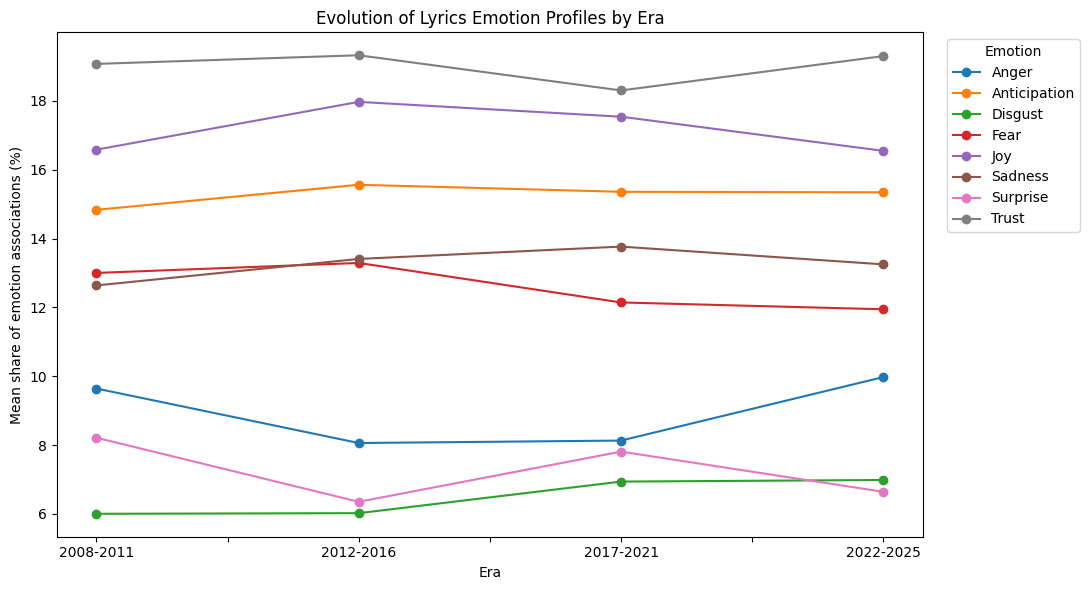

In [83]:
import matplotlib.pyplot as plt

emotion_plot = emotion_by_era.copy() * 100
emotion_plot.columns = [
    col.replace("_share", "").capitalize()
    for col in emotion_plot.columns
]

ax = emotion_plot.plot(
    kind="line",
    marker="o",
    figsize=(11, 6)
)

ax.set_title("Evolution of Lyrics Emotion Profiles by Era")
ax.set_xlabel("Era")
ax.set_ylabel("Mean share of emotion associations (%)")
ax.legend(
    title="Emotion",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Emotion profile evolution

The overall emotional composition of the sampled lyrics remains relatively stable across eras. Trust, joy, and anticipation consistently account for the largest shares of NRC emotion associations.

Some gradual changes are nevertheless visible. Fear decreases across the later eras, while sadness increases until 2017–2021 before declining slightly. Anger decreases after 2008–2011 but rises again in 2022–2025. Joy reaches its highest average share in 2012–2016.

These results describe the relative distribution of NRC emotion associations within the available English-language lyrics sample and should not be interpreted as direct measurements of the emotional tone of the complete listening history.

### 10.2 Emotion profiles by macro-cluster

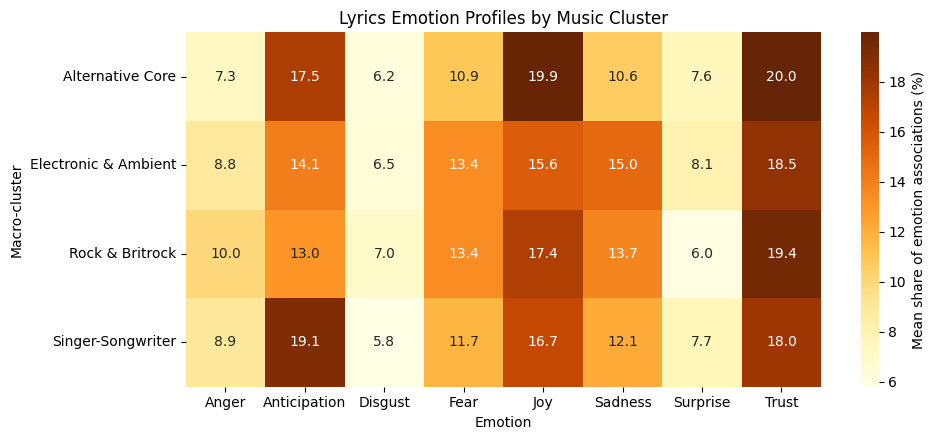

In [85]:
import seaborn as sns

emotion_cluster_plot = emotion_by_macro.copy() * 100

emotion_cluster_plot.columns = [
    col.replace("_share", "").capitalize()
    for col in emotion_cluster_plot.columns
]

plt.figure(figsize=(10, 4.5))

sns.heatmap(
    emotion_cluster_plot,
    annot=True,
    fmt=".1f",
    cmap="YlOrBr",
    cbar_kws={"label": "Mean share of emotion associations (%)"}
)

plt.title("Lyrics Emotion Profiles by Music Cluster")
plt.xlabel("Emotion")
plt.ylabel("Macro-cluster")

plt.tight_layout()
plt.show()

### Emotion profiles by music cluster

The macro-clusters show more distinct emotional profiles than the differences observed across eras.

Alternative Core has the highest average shares of joy and trust and the lowest anger. Electronic & Ambient is characterized by a higher share of sadness, while Rock & Britrock shows the highest anger and relatively high fear. Singer-Songwriter stands out for its high anticipation share.

These differences suggest that the composition of the listening repertoire may be an important factor when interpreting changes in emotion profiles over time.

## 11. Robustness check

## Conclusions